# Tarea 0 --- IELE756
**Team members**: Dario Ampuero, Nicolas Veliz
**Region**: 13 (Región Metropolitana)
**Date**: 11 de marzo de 2026

En esta tarea realizaremos un primer acercamiento a los tres sets de datos del curso: Censo 2024, ENO y GRD, filtrando la información para la Región Metropolitana.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


## Parte 1: Censo 2024
En esta sección cargaremos los datos del Censo 2024 (formato Parquet). Seleccionaremos solo las columnas necesarias para ahorrar memoria, inspeccionaremos la tabla completa y finalmente filtraremos por nuestra región asignada (13) para revisar la distribución de nacionalidad.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("Cargando Censo...")
# Cargar datos
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["region", "comuna", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "escolaridad", "sit_fuerza_trabajo"]
)

# Inspección básica
print(f"Forma de la tabla nacional: {persona.shape}")

# Filtrar por región 13 (Metropolitana)
my_region = persona[persona["region"] == 13]
print(f"\nFilas en la Región Metropolitana: {len(my_region):,}")

# Nacionalidad
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)
print(f"% de residentes extranjeros: {foreign.get('Extranjero', 0):.1%}")

Cargando Censo...
Forma de la tabla nacional: (18480432, 8)

Filas en la Región Metropolitana: 7,400,741
% de residentes extranjeros: 0.0%


## Parte 2: ENO - Enfermedades de Notificación Obligatoria
A continuación, cargaremos el dataset ENO (formato CSV). Filtraremos por texto para la Región Metropolitana y graficaremos las notificaciones por año, así como las 5 enfermedades más frecuentes.

Cargando ENO...


/tmp/ipykernel_31588/637187084.py:6: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv("20241218_base_eno_final.csv", sep=";", encoding="utf-8-sig")


Notificaciones en la región: 126,669


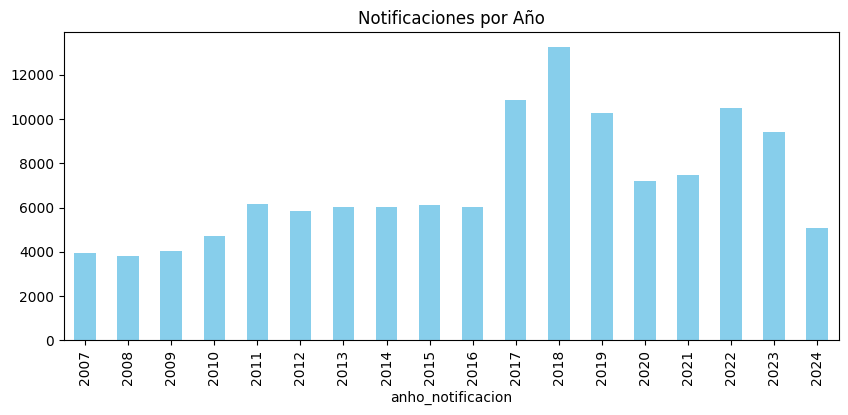

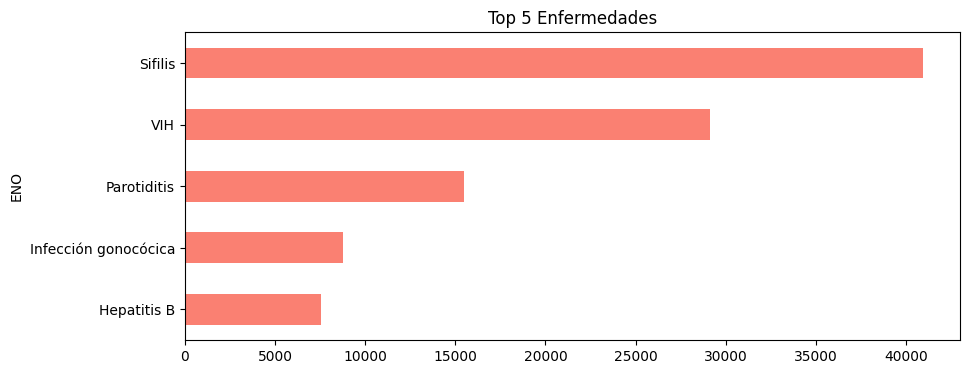


Distribución de nacionalidad:
nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

print("Cargando ENO...")
# Cargar datos
eno = pd.read_csv("20241218_base_eno_final.csv", sep=";", encoding="utf-8-sig")

# Filtrar por región
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Notificaciones en la región: {len(eno_region):,}")

# Gráfico por año
notificaciones_ano = eno_region["anho_notificacion"].value_counts().sort_index()
notificaciones_ano.plot(kind="bar", title="Notificaciones por Año", color='skyblue', figsize=(10,4))
plt.show()

# Top 5 enfermedades
top_enfermedades = eno_region["ENO"].value_counts().head(5)
top_enfermedades.plot(kind="barh", title="Top 5 Enfermedades", color='salmon', figsize=(10,4))
plt.gca().invert_yaxis()
plt.show()

# Distribución de nacionalidad
print("\nDistribución de nacionalidad:")
print(eno_region["nacionalidad"].value_counts())

## Parte 3: GRD - Altas Hospitalarias
Finalmente, cargaremos los datos de GRD de 2024. Como este dataset no incluye una columna de región, filtraremos usando una lista de las principales comunas de la Región Metropolitana. Luego, cruzaremos los datos con la tabla CIE-10 para obtener las descripciones de los diagnósticos.

Cargando GRD...
Altas hospitalarias en estas comunas: 108,998
Cruzando con diccionario CIE-10...


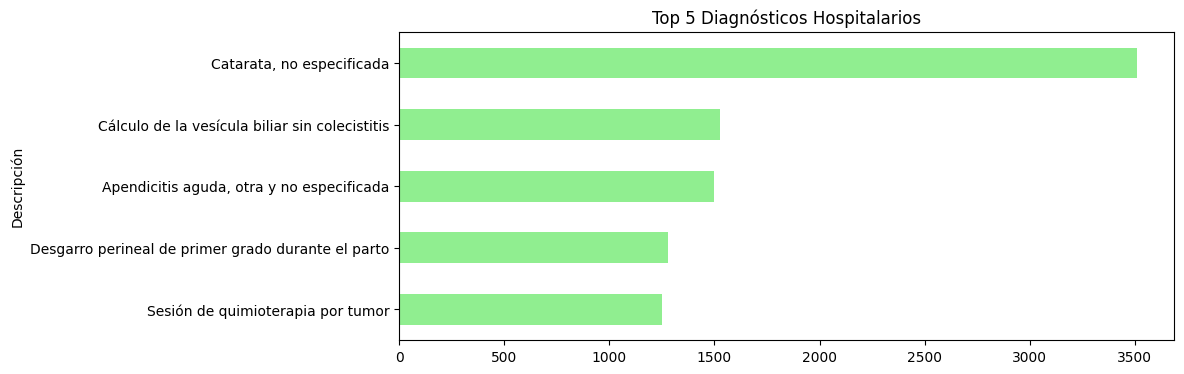

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

print("Cargando GRD...")
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

# Cargar el archivo TXT directamente
grd = pd.read_csv("GRD_PUBLICO_2024.txt", sep="|", usecols=cols, low_memory=False, encoding="latin-1")

# Filtrar por algunas comunas de la RM
my_comunas = ["SANTIAGO", "PROVIDENCIA", "LAS CONDES", "MAIPU", "LA FLORIDA", "PUENTE ALTO"]
grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Altas hospitalarias en estas comunas: {len(grd_region):,}")

print("Cruzando con diccionario CIE-10...")
# Unir con CIE-10
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")
grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left"
)

# Top 5 diagnósticos
top_diagnosticos = grd_region["Descripción"].value_counts().head(5)
top_diagnosticos.plot(kind="barh", title="Top 5 Diagnósticos Hospitalarios", color='lightgreen', figsize=(10,4))
plt.gca().invert_yaxis()
plt.show()

### Subiendo archivos a Google Colab

Para que tu código pueda acceder a los archivos de datos (`personas_censo2024.parquet`, `20241218_base_eno_final.csv`, `GRD_PUBLICO_2024.zip`, y `CIE-10.xlsx`), necesitas subirlos a tu entorno de Colab. Puedes hacerlo usando el siguiente código, que abrirá un diálogo para seleccionar los archivos desde tu máquina local.

In [ ]:
from google.colab import files

# Sube personas_censo2024.parquet
print('Por favor, sube el archivo personas_censo2024.parquet')
uploaded_censo = files.upload()

# Sube 20241218_base_eno_final.csv
print('\nPor favor, sube el archivo 20241218_base_eno_final.csv')
uploaded_eno = files.upload()

# Sube GRD_PUBLICO_2024.txt (no el .zip)
print('\nPor favor, sube el archivo GRD_PUBLICO_2024.txt')
uploaded_grd_txt = files.upload()

# Sube CIE-10.xlsx
print('\nPor favor, sube el archivo CIE-10.xlsx')
uploaded_cie10 = files.upload()

print('\nTodos los archivos han sido subidos.')

Por favor, sube el archivo personas_censo2024.parquet



Por favor, sube el archivo 20241218_base_eno_final.csv


### Descomprimiendo el archivo GRD_PUBLICO_2024.zip

Una vez que el archivo `GRD_PUBLICO_2024.zip` esté subido, necesitamos descomprimirlo para acceder al archivo `GRD_PUBLICO_2024.txt` que contiene los datos.

In [ ]:
# Este paso ya no es necesario porque GRD_PUBLICO_2024.txt se sube directamente, no se descomprime de un ZIP.
print("El archivo GRD_PUBLICO_2024.zip no existe y no es necesario descomprimirlo. Se espera que GRD_PUBLICO_2024.txt se suba directamente.")

Después de ejecutar los pasos anteriores para subir y descomprimir los archivos, puedes intentar ejecutar las celdas de código originales que causaron los errores. Ahora deberían poder encontrar los archivos.